# ANN for Delivery Time Prediction – Porter Business Case
**Goal**: Build and evaluate Artificial Neural Network regression model to estimate delivery time based on order and fulfillment-related features.


## Dataset Overview

This dataset contains records of food deliveries fulfilled by Porter's intra-city logistics platform. Each row represents one unique delivery, with features covering:

- **Order Metadata**: `created_at`, `actual_delivery_time`, `order_protocol`, `store_primary_category`
- **Order Contents**: `total_items`, `num_distinct_items`, `min_item_price`, `max_item_price`, `subtotal`
- **Operational Features**: `market_id`, `total_onshift_partners`, `total_busy_partners`, `total_outstanding_orders`
- **Delivery Estimate**: `estimated_store_to_consumer_driving_duration`

### 🎯 Target Variable
Derived from timestamps:  
```python
delivery_time_mins = (actual_delivery_time - created_at).total_seconds() / 60


## Model Evolution

The modeling journey was structured into five iterative phases:

| Phase | Description |
|-------|-------------|
| **1. Baseline ANN** | Built a simple feedforward ANN with default settings to establish a benchmark |
| **2. Encoding Experiments** | Compared One-Hot Encoding vs Target Encoding for categorical features |
| **3. Optimizer & Activation Trials** | Tried various configurations (ReLU, Sigmoid with Adam/RMSProp) |
| **4. Hyperparameter Tuning** | Applied manual tuning and KerasTuner to optimize learning rate, layers, dropout |
| **5. Polynomial Features** | Introduced 2nd-degree polynomial features to capture interactions |

In [4]:
import pandas as pd

df = pd.read_excel("01_ANN_Experiments_00.xlsx")
df = df[['Name', 'Optimiser', 'MSE', 'RMSE', 'MAE', 'R2']].dropna()
df = df.sort_values('R2', ascending=False).reset_index(drop=True)
df.head(10)  # Top 10 models


,Name,Optimiser,MSE,RMSE,MAE,R2
0,ANN_Porter_poly_04_adam.ipynb,Adam(learning_rate=0.0005),185.56,13.62,10.61,0.31
1,ANN_Porter_poly_03_adam.ipynb,HPT adam,185.56,13.62,10.61,0.31
2,ANN_Porter_poly_02_adam.ipynb,Adam(learning_rate=0.0005),186.51,13.66,10.64,0.31
3,ANN_Porter_poly_06_adam.ipynb,Adam(learning_rate=0.0005),187.75,13.70,10.65,0.30
4,ANN_Porter_poly_05_adam.ipynb,Adam(learning_rate=0.0005),187.73,13.70,10.68,0.30
5,ANN_Porter_poly_01_adam.ipynb,Adam(learning_rate=0.0003),189.27,13.76,10.71,0.30
6,ANN_Porter_poly_00_adam.ipynb,Adam(learning_rate=0.0003),188.35,13.72,10.72,0.30
7,ANN_Porter_New_00_adam.ipynb,Adam(learning_rate=0.0003),191.87,13.85,10.80,0.28
8,ANN_Porter_New_03B_adam_HPT.ipynb,Adam(learning_rate=0.0003),190.98,13.82,0.76,0.28
9,ANN_Porter_New_02.01_adam_6_HL.ipynb,Adam(learning_rate=0.0003),190.79,13.81,10.70,0.28


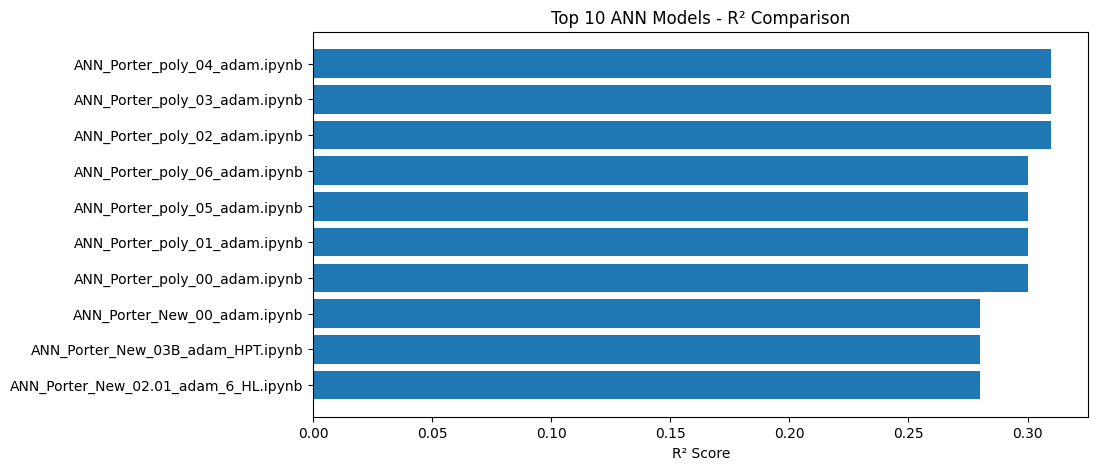

In [6]:
import matplotlib.pyplot as plt

top_models = df.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_models['Name'], top_models['R2'])
plt.xlabel("R² Score")
plt.title("Top 10 ANN Models - R² Comparison")
plt.gca().invert_yaxis()
plt.show()


## Key Learnings

- Polynomial features improved baseline ANN model R² from 0.25 to ~0.31
- Target encoding outperformed One-Hot in most models
- ReLU activation and Adam optimizer gave the best results
- Despite extensive tuning, ANN struggled to capture more than 31% variance
- Feature Engineering had a greater impact than model tuning


## Conclusion

While ANN offers flexibility, the current dataset seems to lack enough predictive power for high R² scores. Even with polynomial interactions and hyperparameter tuning, the ceiling was ~0.31. This project underscores the importance of strong features and that deep models cannot always compensate for low signal.

Future work could include:
- External features like traffic, weather, or warehouse load
- Tree-based models for interpretability
- SHAP analysis for feature impact
